# Tugas Hands-On 3 Digital Signal Processing

NIM: 122140008

In [19]:
## Import dependencies
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.signal as signal
import pandas as pd

In [20]:
## Create faceDetector Object

## Define the models
base_model="blaze_face_short_range.tflite"
base_options = python.BaseOptions(model_asset_path=base_model)

## Mediapipe configuration options
FaceDetectorOptions = vision.FaceDetectorOptions
VisionRunningMode = vision.RunningMode
options = FaceDetectorOptions(
    base_options=base_options,
    running_mode = VisionRunningMode.IMAGE,
)
face_detector = vision.FaceDetector.create_from_options(options)

In [21]:
## Create Pose Landmarker Object

## Define the models
model_path = "pose_landmarker.task"
BaseOptions = mp.tasks.BaseOptions

PoseLandmarkerOptions = vision.PoseLandmarkerOptions
VisionRunningMode = vision.RunningMode

options_image = PoseLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=model_path,
    ),
    running_mode=VisionRunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False
)

pose_landmarker = vision.PoseLandmarker.create_from_options(options_image)

<h1>POS (Plane-Orthogonal to Skin)</h1>

POS (Plane-Orthogonal-to-Skin) adalah sebuah metode dalam remote photoplethysmography (rPPG) untuk mendeteksi detak jantung tanpa kontak langsung, cukup dari video wajah seseorang.

In [22]:
## Core method POS 
def POS(signal, **kargs):
    """
    POS method on CPU using Numpy.

    The dictionary parameters are: {'fps':float}.

    Wang, W., den Brinker, A. C., Stuijk, S., & de Haan, G. (2016). Algorithmic principles of remote PPG. IEEE Transactions on Biomedical Engineering, 64(7), 1479-1491. 
    """
    """
    eps: A small constant (10^-9) used to prevent division by zero in normalization steps.
    X: The input signal, which is a 3D array where:
    e: Number of estimators or regions in the frame (like different parts of the face).
    c: Color channels (3 for RGB).
    f: Number of frames.
    w: Window length, determined by the camera's frame rate (fps). For example, at 20 fps, w would be 32 (which corresponds to about 1.6 seconds of video).
    """
    eps = 10**-9
    X = signal
    e, c, f = X.shape # Number of estimators, color channels, and frames
    w = int(1.6 * kargs['fps']) # Window length in frames

    """
    P: A fixed 2x3 matrix used for the projection step. It defines how to transform the color channels (RGB) into a new space.
    Q: This is a stack of the matrix P repeated e times, where each P corresponds to an estimator (region of interest) in the video.
    """
    P = np.array([[0, 1, -1], [-2, 1, 1]])
    Q = np.stack([P for _ in range(e)], axis = 0)

    """
    H: A matrix to store the estimated heart rate signal over time for each estimator.
    n: The current frame in the sliding window.
    m: The start index of the sliding window (calculating which frames are part of the current window).
    """
    H = np.zeros((e, f))
    for n in np.arange(w, f):
        # Start index of sliding window 
        m = n - w + 1

        """
        Temporal Normalization (Equation 5 from the paper): This step ensures that the signal is invariant to global lighting changes and other noise factors.
        """
        Cn = X[:, :, m:(n+1)]
        M = 1.0 / (np.mean(Cn, axis = 2) + eps)
        M = np.expand_dims(M, axis=2) # shape [e, c, w]
        Cn = np.multiply(Cn, M)

        """
        Projection (Equation 6 from the paper): This step transforms the RGB values into a space where the signal from blood flow (heart rate) is more distinct.
        """
        S = np.dot(Q, Cn)
        S = S[0, :, :, :]
        S = np.swapaxes(S, 0, 1) 

        """
        Tuning (Equation 7 from the paper): This step adjusts the projected components to make the heart rate signal clearer.
        """
        S1 = S[:, 0, :]
        S2 = S[:, 1, :]
        alpha = np.std(S1, axis=1) / (eps + np.std(S2, axis=1))
        alpha - np.expand_dims(alpha, axis=1)
        Hn = np.add(S1, alpha * S2)
        Hnm = Hn - np.expand_dims(np.mean(Hn, axis=1), axis=1)

        """
        Overlap-Adding (Equation 8 from the paper): This step combines the processed signals from each frame to form the final output heart rate signal.
        """
        H[:, m:(n + 1)] = np.add(H[:, m:(n + 1)], Hnm)  # Add the tuned signal to the output matrix

    return H


In [23]:
## Some variables, containers, constants and buffer
r_signal, g_signal, b_signal = [], [], [] ## For storing RGB value from the skin
fps = 35 ## Frame rate of the camera
time_window = 60 # Time window in seconds
frame_buffer_limit = time_window * fps ## Number of frames to be processed
frame_buffer = [] ## Buffer for storing frames
margin_x = 10  # Adjust horizontally
scaling_factor = 0.8 # Scaling factor for the bounding box


An error occurred: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'



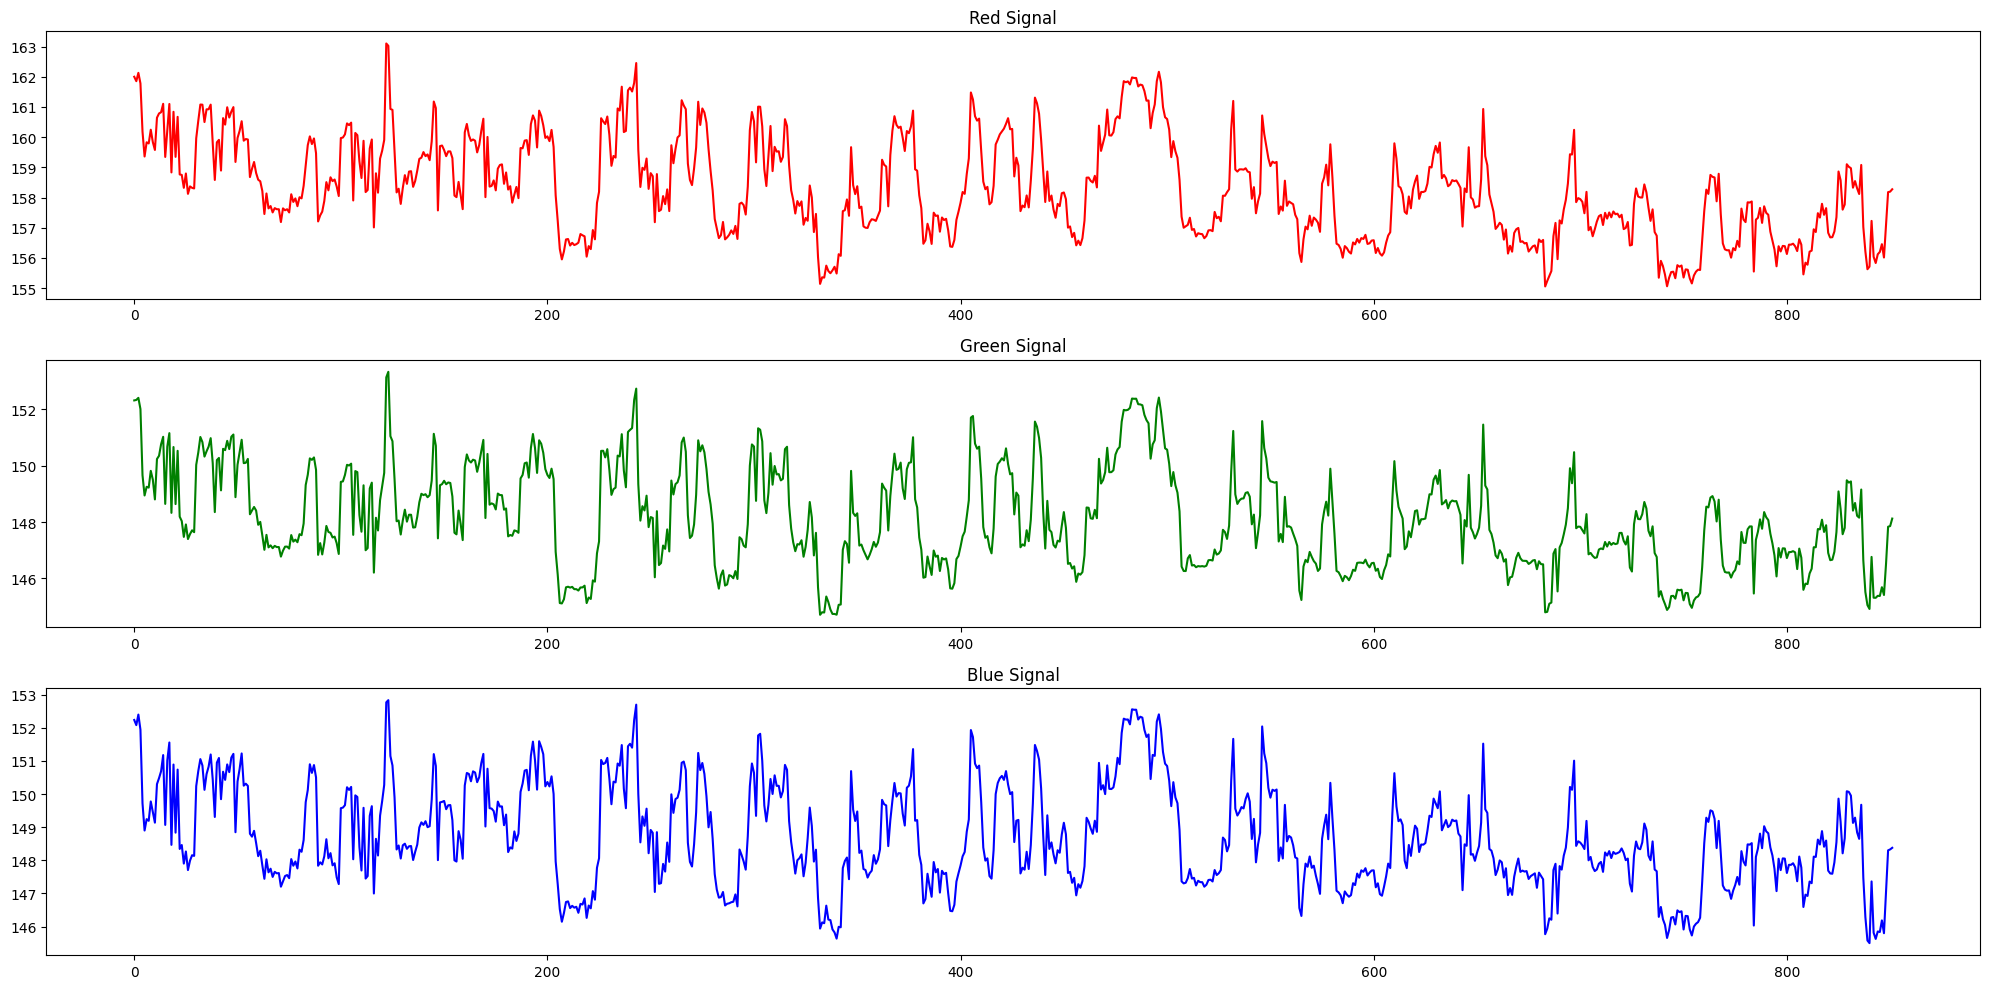

In [24]:
try:
    ## Load the Video
    file_path = os.path.join("media/Bintang_resp.mp4") ## Path to the video file
    
    ## Put 0 to use the camera, or use the video file path for analyzing a video
    cap = cv2.VideoCapture(file_path)
    STANDARD_SIZE = (800, 600)

    if not cap.isOpened():
        print("Error: Could not open video.")
        exit()

    ## Untuk mendapatkan 60 detik video.
    while len(frame_buffer) < frame_buffer_limit:

        ## Read the frame from the camera
        ret, frame = cap.read()
        frame = cv2.resize(frame, STANDARD_SIZE)
        if not ret:
            print("Error: Could not read frame.")
            break

        ## Adding the frame_buffer to the list
        frame_buffer.append(frame)

        ## Convert the frame to RGB
        ## Karena default dari OpenCV adalah BGR, kita perlu mengkonversi ke RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        ## Seting up the Mediapipe Image
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb_frame
        )

        ## Process the frame using the face detector
        result = face_detector.detect(mp_image)

        if result.detections:
            for detection in result.detections:

                ## Get the Bounding box
                bboxC = detection.bounding_box
                x, y, w, h = bboxC.origin_x, bboxC.origin_y, bboxC.width, bboxC.height

                ## Setup tipis tipis biar boxnya pas di tengah wajah
                new_x = int(x + margin_x)
                new_w = int(w * scaling_factor)
                new_h = int(h * scaling_factor)

                ## Get the ROI
                face_roi = rgb_frame[y:y+new_h, new_x:new_x+new_w]
            
                ## Draw the bounding box on the frame
                cv2.rectangle(frame, (int(x), int(y)), (int(x + new_w), int(y + new_h)), (0, 255, 0), 2)

                ## Calculate the Mean RGB values of the face ROI
                mean_rgb = cv2.mean(face_roi)[:3]
                
                # Append the combined RGB values to the respective lists
                r_signal.append(mean_rgb[0])
                g_signal.append(mean_rgb[1])
                b_signal.append(mean_rgb[2])

        # Show the frame
        cv2.imshow("frame", frame) 

        # Check if 'q' is pressed or the window is closed
        if cv2.waitKey(1) & 0xFF == ord('q') or cv2.getWindowProperty("frame", cv2.WND_PROP_VISIBLE) < 1:
            break

except Exception as e:
    print(f"An error occurred: {e}")
    cap.release()
    cv2.destroyAllWindows()

finally:
    ## Release the camera and close all windows
    cap.release()
    cv2.destroyAllWindows()

    ax, fig = plt.subplots(3, 1, figsize=(20, 10))
    fig[0].plot(r_signal, color='red')
    fig[0].set_title('Red Signal')
    fig[1].plot(g_signal, color='green')
    fig[1].set_title('Green Signal')
    fig[2].plot(b_signal, color='blue')
    fig[2].set_title('Blue Signal')
    plt.tight_layout()
    plt.show()

<img src='media/pos.png'>

Proses ini melakukan deteksi wajah pada frame video untuk mendapatkan bounding box wajah. Kemudian, bounding box ini digunakan untuk mendapatkan ROI (Region of Interest) dari wajah, yang kemudian digunakan untuk menghitung nilai rata-rata RGB dari area tersebut. Nilai rata-rata RGB ini disimpan dalam list r_signal, g_signal, dan b_signal untuk analisis lebih lanjut.

<h1>Post-Processing rPPG signals</h1>

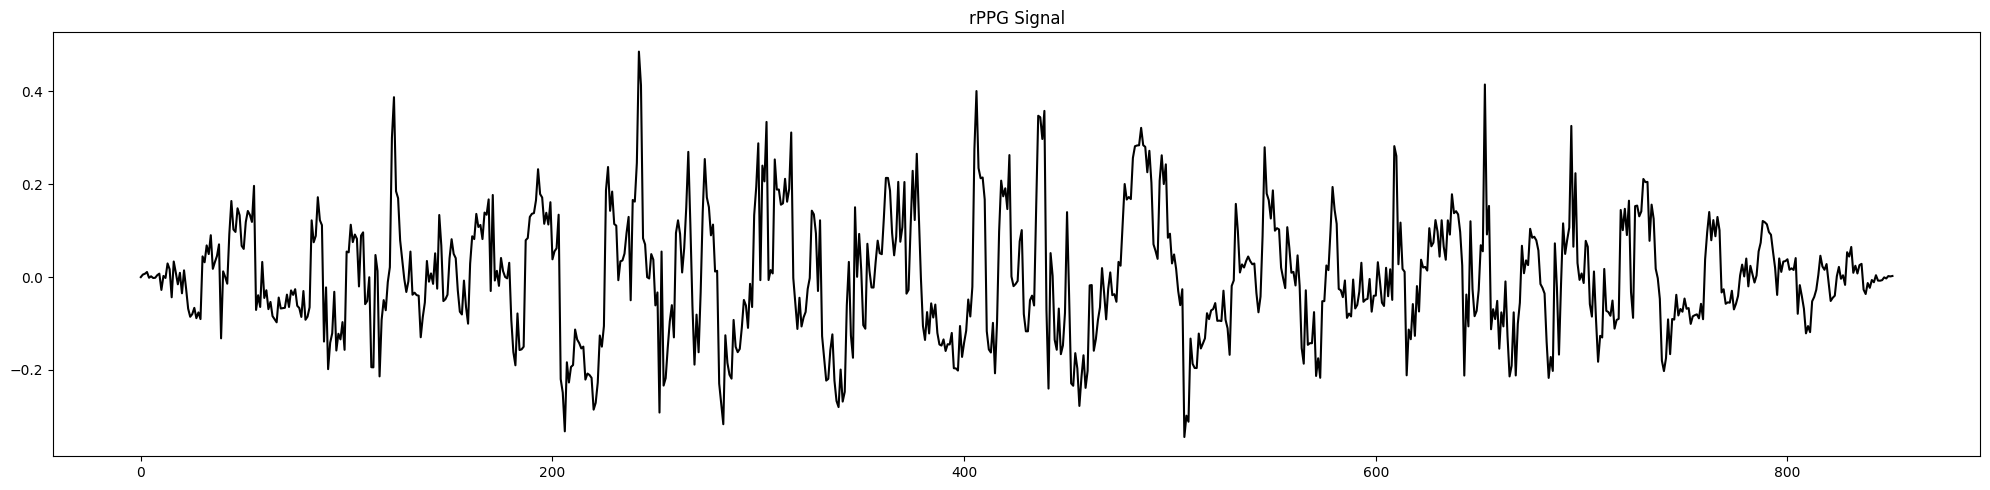

In [25]:
# Menghitung rPPG menggunakan Metode POS
rgb_signals = np.array([r_signal, g_signal, b_signal])
rgb_signals = rgb_signals.reshape(1, 3, -1)
rppg_signal = POS(rgb_signals, fps=30)
rppg_signal = rppg_signal.reshape(-1)

# 6.1 Menampilkan grafik Sinyal rPPG
plt.figure(figsize=(20, 5))
plt.plot(rppg_signal, color='black')
plt.title('rPPG Signal')
plt.tight_layout()
plt.show()


Sinyal yang diperoleh masih cukup raw (mentah), masih belum bisa dilakukan analisis lebih lanjut tanpa post-processing.

Pada tahapan ini akan dilakukan post-processing untuk melakukan filtering sinyal dan menentukan peak dari sinyal yang merupkan tanda dari detak jantung.
Tahapan pertama yakni merubah sinyal RGB menjadi rPPG.

<h1>Post-Processing dan Analysis</h1>

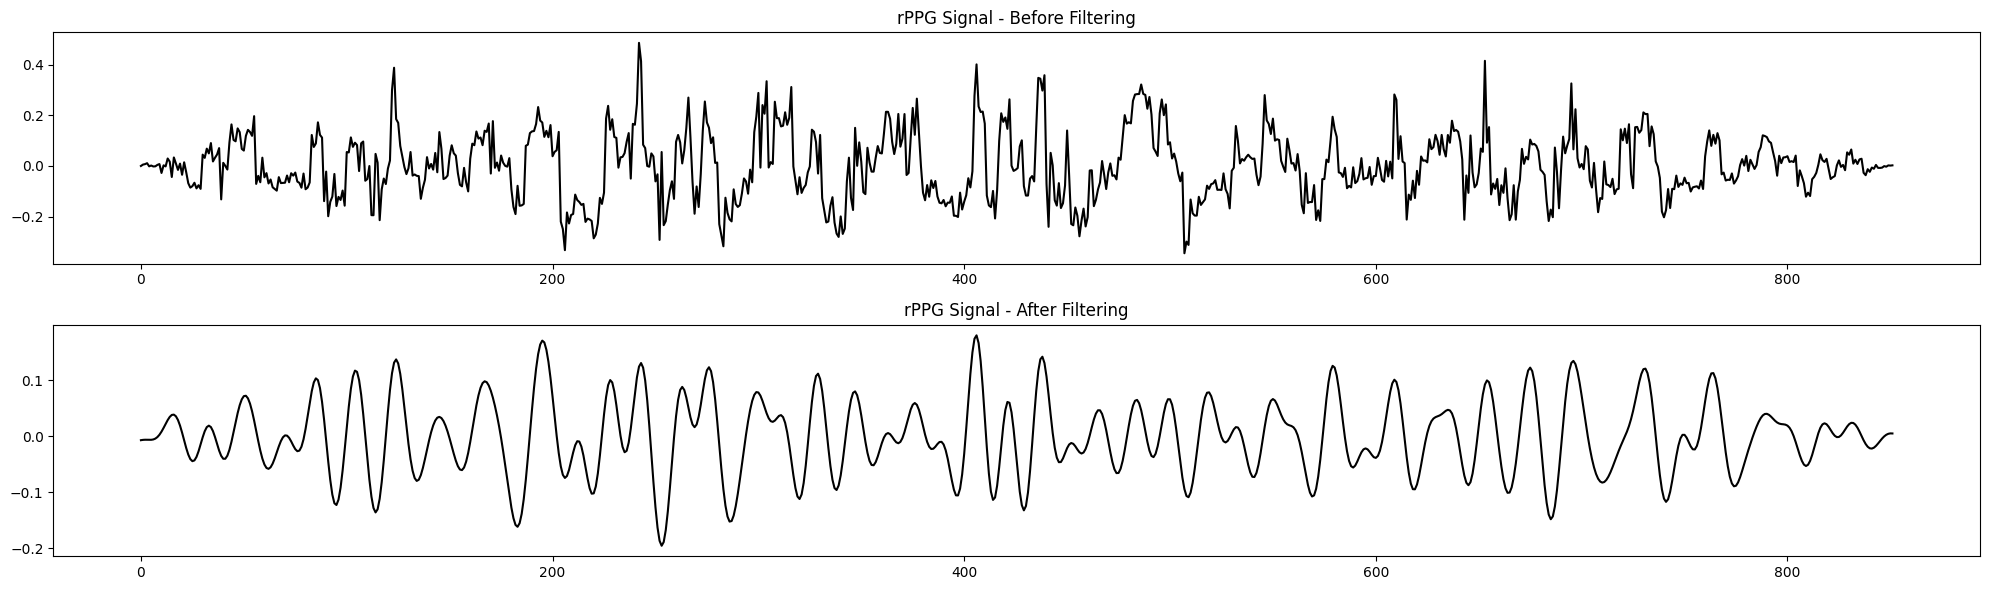

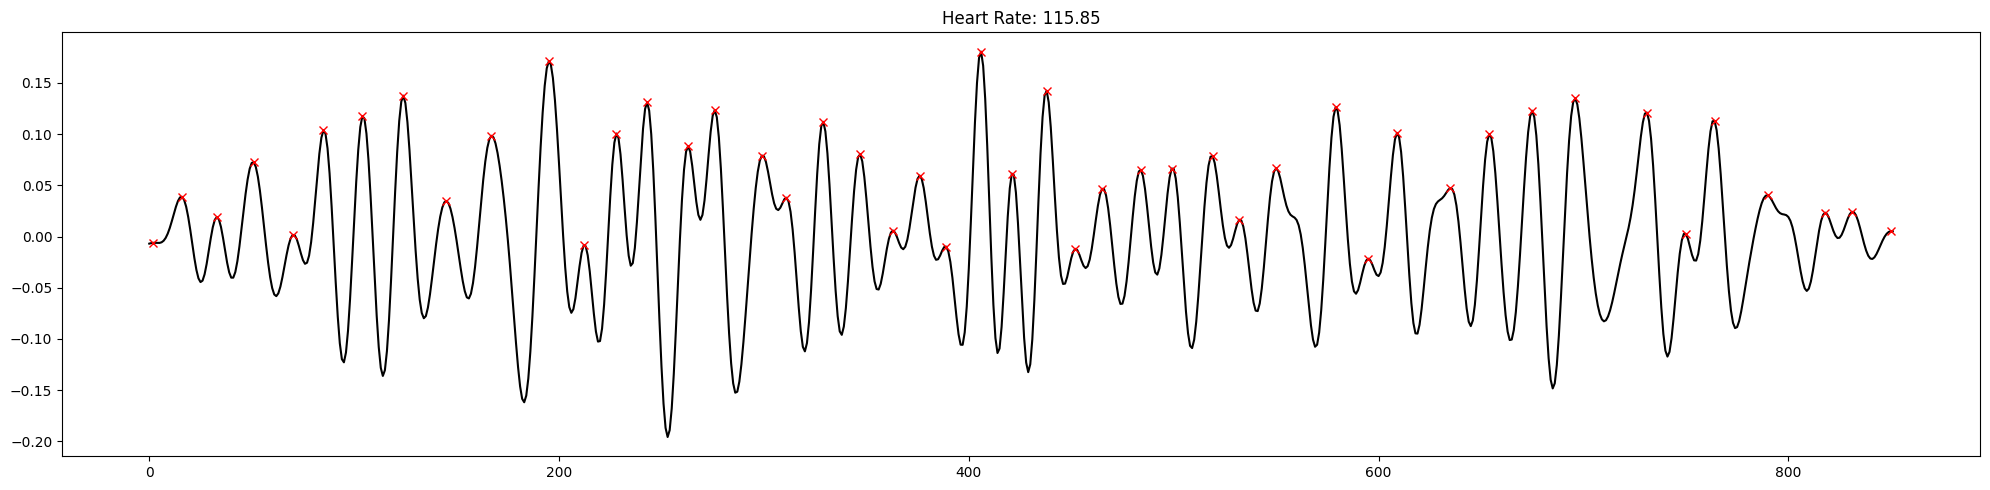

In [26]:
# Memfilter Sinyal rPPG
fs = 35; lowcut = 0.9; highcut = 2.4; order = 3
b, a = signal.butter(order, [lowcut, highcut], btype='band', fs=fs)
filtered_rppg = signal.filtfilt(b, a, rppg_signal)

fig, ax = plt.subplots(2, 1, figsize=(20, 6))
ax[0].plot(rppg_signal, color='black')
ax[0].set_title('rPPG Signal - Before Filtering')
ax[1].plot(filtered_rppg, color='black')
ax[1].set_title('rPPG Signal - After Filtering')
plt.tight_layout()
plt.show()

# Mencari puncak sinyal
peaks, _ = signal.find_peaks(
    x=filtered_rppg,
)

# Menghitung heart rate
heart_rate = 60 * len(peaks) / (len(filtered_rppg) / fs)

# Menampilkan grafik puncak sinyal
plt.figure(figsize=(20, 5))
plt.plot(filtered_rppg, color='black')
plt.plot(peaks, filtered_rppg[peaks], 'x', color='red')
plt.title(f'Heart Rate: {heart_rate:.2f}')
plt.tight_layout()
plt.show()


1. Grafik rPPG Sebelum dan Sesudah Filtering  
    - Bagian atas menunjukkan sinyal rPPG sebelum filtering, sehingga sulit untuk mengidentifikasi pola detak jantung.  
    - Bagian bawah menunjukkan sinyal rPPG setelah melalui proses filtering bandpass.

2. Grafik Heart Rate  
    Grafik menampilkan sinyal rPPG hasil ekstraksi dari video, di mana puncak-puncak sinyal yang terdeteksi ditandai dengan tanda silang merah. Setiap puncak mewakili satu siklus detak jantung. Nilai heart rate yang dihitung dari jumlah puncak per durasi sinyal ditampilkan di bagian atas grafik.


<h1>Respiration - The Rhythm Beneath the Breath</h1>

# Lukas-Kanade Optical Flow

## Apa itu Optical Flow?
<p>Optikal Flow adalah teknik dalam <i>computer vision</i> untuk menghitung gerakan objek antar dua frame gambar berdasarkan perubahan intensitas (kecerahan) piksel dari waktu ke waktu</p>

## Metode Lucas-Kanade
<p>Lucas-Kanade adalah metode lokal (lokal = fokus pada area kecil) untuk memperkirakan optical flow.
Lucas-Kanade bekerja berdasarkan 2 asumsi, yaitu bahwa aliran bersifat halus secara lokal dan Piksel yang
ber-tetangga memiliki perpindahan yang sama</p>

## Langkah Implementasi Lucas-Kanade untuk Menangkap Sinyal Respirasi
1. Ambil dan siapkan data Video.
2. Memilih titik awal pada bahu dengan bantuan model pose landmarker (terutama pada poin 11 & 12 untuk bahu kanan & kiri).
3. Hitung Optical Flow menggunakan Lucas-Kanade untuk melacak perpindahan titik-titik bahu dari satu frame ke frame lainnya.
4. Analisis gerakan titik bahu dengan fokus pada komponen vertikal (arah naik-turun) gerakan bahu.
5. Menghitung berapa kali terjadi pola naik-turun = jumlah napas.

<h2>Mediapipe Pose Landmarker</h2>

In [35]:
## Setup variables, constants and etc..
resp_signal = []
fps = 35 ## Frame rate of the camera
time_window = 60 # Time window in seconds
frame_buffer_limit = time_window * fps ## Number of frames to be processed, since toby-rgb is 60 seconds
frame_buffer = [] ## Buffer for storing frames
features = None # for storing the features optical flow.
lk_params = None ## Lucas-Kanade parameters
old_gray = None ## Old gray frame
left_x, top_y, right_x, bottom_y = None, None, None, None ## Coordinates for the ROI
STANDARD_SIZE = (640, 480)  # Pick whatever size you want

In [36]:
## Create Pose Landmarker Object

## Define the models
model_path = "pose_landmarker.task"
BaseOptions = mp.tasks.BaseOptions

PoseLandmarkerOptions = vision.PoseLandmarkerOptions
VisionRunningMode = vision.RunningMode

options_image = PoseLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=model_path,
    ),
    running_mode=VisionRunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False
)

pose_landmarker = vision.PoseLandmarker.create_from_options(options_image)

In [37]:
# Function to get the Initial ROI for Tracking with Optical Flow
def get_initial_roi(image, landmarker, x_size = 100, y_size=100, shift_x=0, shift_y=0):
    """
    Mendapatkan ROI awal berdasarkan posisi bahu menggunakan pose detection.
    Args:
        image: Frame video input
        landmarker: Model pose detector
        x_size: Jarak piksel dari titik tengah ke tepi kiri/kanan
        y_size: Jarak piksel dari titik tengah ke tepi atas/bawah
        shift_x: Pergeseran horizontal kotak (negatif=kiri, positif=kanan)
        shift_y: Pergeseran vertikal kotak (negatif=atas, positif=bawah)
    """
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]

    ## Create Mediapipe image
    mp_image = mp.Image(
        image_format = mp.ImageFormat.SRGB,
        data = image_rgb
    )

    ## Inference Detect Landmarks
    detection_result = landmarker.detect(mp_image)

    if not detection_result.pose_landmarks:
        raise ValueError("No pose detected in the frame")
    
    landmarks = detection_result.pose_landmarks[0]

    ## Get should position from the landmarks
    left_shoulder = landmarks[11]
    right_shoulder = landmarks[12]

    ## Calculate the center point between should before creating the ROI Bounds
    center_x = int((left_shoulder.x + right_shoulder.x) * width / 2)
    center_y = int((left_shoulder.y + right_shoulder.y) * height / 2)

    ## Apply shift to the center point (offset from the chest)
    center_x += shift_x
    center_y += shift_y

    ## Create the ROI Bounds from the center point and sizes
    left_x = max(0, center_x - x_size)
    right_x = min(width, center_x + x_size)
    top_y = max(0, center_y - y_size)
    bottom_y = min(height, center_y)

    ## Validate ROI size
    if (right_x - left_x) <= 0 or (bottom_y - top_y) <= 0:
        raise ValueError("Invalid ROI dimensions")
    
    ## Return top, left, bottom, right points
    return (left_x, top_y, right_x, bottom_y)

In [38]:
def initialize_features(frame):
    """
    Metode untuk mendapatkan nilai features untuk keperluan optical flow dan membuat object Lucas Kanade sebagai argument dari optical flow itu sendiri.
    frame: cv2Object = frame sumber dari kamera untuk melakukan deteksi ROI dada dan bahu
    """
    global features, lk_params, old_gray, left_x, top_y, right_x, bottom_y, STANDARD_SIZE   # Declare them as global to modify the outer variables

    roi_coords = get_initial_roi(frame, pose_landmarker)
    left_x, top_y, right_x, bottom_y = roi_coords
    
    frame = cv2.resize(frame, STANDARD_SIZE)
    old_frame = frame.copy()
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
    roi_chest = old_gray[top_y:bottom_y, left_x:right_x]
    features = cv2.goodFeaturesToTrack(roi_chest, maxCorners=50, qualityLevel=0.2, minDistance=5, blockSize=3)
    if features is None:
        raise ValueError("No features found to track!")
    features = np.float32(features)
    features[:,:,0] += left_x
    features[:,:,1] += top_y
    old_gray = old_gray
    lk_params = dict(winSize=(15, 15), maxLevel=2, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

Error: Could not read frame.


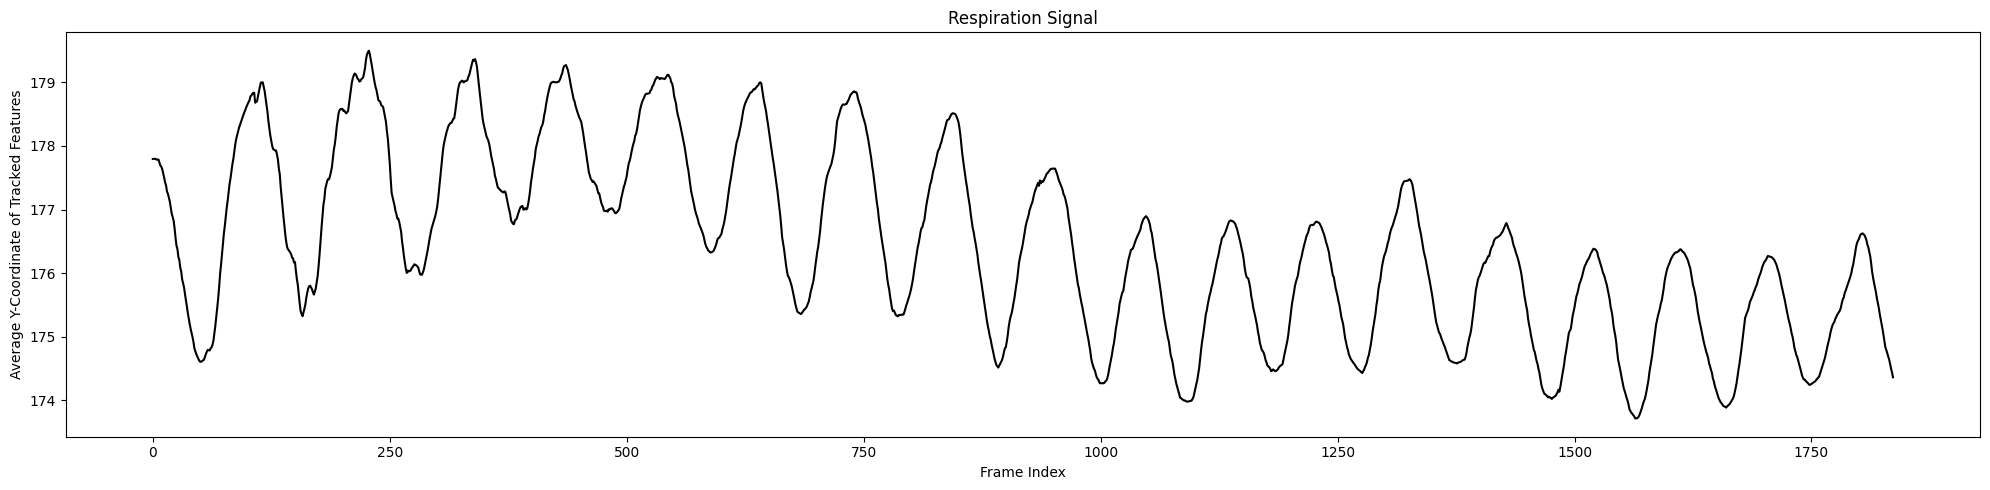

In [39]:
try:
    ## Load the Video
    file_path = os.path.join("media/Bintang_resp.mp4") ## Path to the video file
    
    ## Put 0 to use the camera, or use the video file path for analyzing a video
    cap = cv2.VideoCapture(file_path) 

    if not cap.isOpened():
        print("Error: Could not open video.")
        exit()

    ## Untuk mendapatkan 60 detik video.
    while len(frame_buffer) < frame_buffer_limit:

        ## Read the frame from the camera
        ret, frame = cap.read() 
        if not ret:
            print("Error: Could not read frame.")
            break

        frame = cv2.resize(frame, STANDARD_SIZE)
        ## Adding the frame_buffer to the list
        frame_buffer.append(frame)

        if features is None:
            # Initialize ROI and feature detection
            initialize_features(frame)

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if len(features) > 10:
            new_features, status, error = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, features, None, **lk_params)
            good_old = features[status == 1]
            good_new = new_features[status == 1]
            mask = np.zeros_like(frame)
            for i, (new, old) in enumerate(zip(good_new, good_old)):
                a, b = new.ravel()
                c, d = old.ravel()
                mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), (0, 255, 0), 2)
                frame = cv2.circle(frame, (int(a), int(b)), 3, (0, 255, 0), -1)
            frame = cv2.add(frame, mask)
            if len(good_new) > 0:
                avg_y = np.mean(good_new[:, 1])
                resp_signal.append(avg_y)
                features = good_new.reshape(-1, 1, 2)
            old_gray = frame_gray.copy()
        else:
            # Reinitialize features if tracking fails
            initialize_features(frame)

        ## Plot bounding box
        cv2.rectangle(frame, (int(left_x), int(top_y)), (int(right_x), int(bottom_y)), (0, 255, 0), 2)
        
        # Show the frame
        cv2.imshow("frame", frame) 

        # Check if 'q' is pressed or the window is closed
        if cv2.waitKey(1) & 0xFF == ord('q') or cv2.getWindowProperty("frame", cv2.WND_PROP_VISIBLE) < 1:
            break

except Exception as e:
    print(f"An error occurred: {e}")
    cap.release()
    cv2.destroyAllWindows()

finally:
    ## Release the camera and close all windows
    cap.release()
    cv2.destroyAllWindows()
    
    ## Plot the Respiration Signal
    plt.figure(figsize=(20, 5))
    plt.plot(resp_signal, color='black')
    plt.title('Respiration Signal')
    plt.xlabel('Frame Index')
    plt.ylabel('Average Y-Coordinate of Tracked Features')
    plt.tight_layout()
    plt.show()


## Hasil Sinyal Respirasi dengan Metode Lucas-Kanade Optical Flow
<p>Grafik di atas menunjukkan pola naik-turun yang menggambarkan proses pernapasan seseorang. Setiap gelombang naik dan turun mewakili satu kali tarikan dan hembusan napas. Sumbu mendatar (X) adalah urutan frame dari video, sedangkan sumbu tegak (Y) menunjukkan posisi rata-rata titik-titik yang dilacak di bahu.</p>

<img src='media/landmarker.png'>

Program akan melakukan deteksi dengan menggambar bounding box disekitar bahu sesuai dengan pose landmark yang telah di tetapkan (11 & 12) pada bahu kanan dan bahu kiri. Kemudian pergerakan bahu yang ke atas dan ke bawah akan menghasilkan data berupa sinyal naik turun yang kemudian di plot.

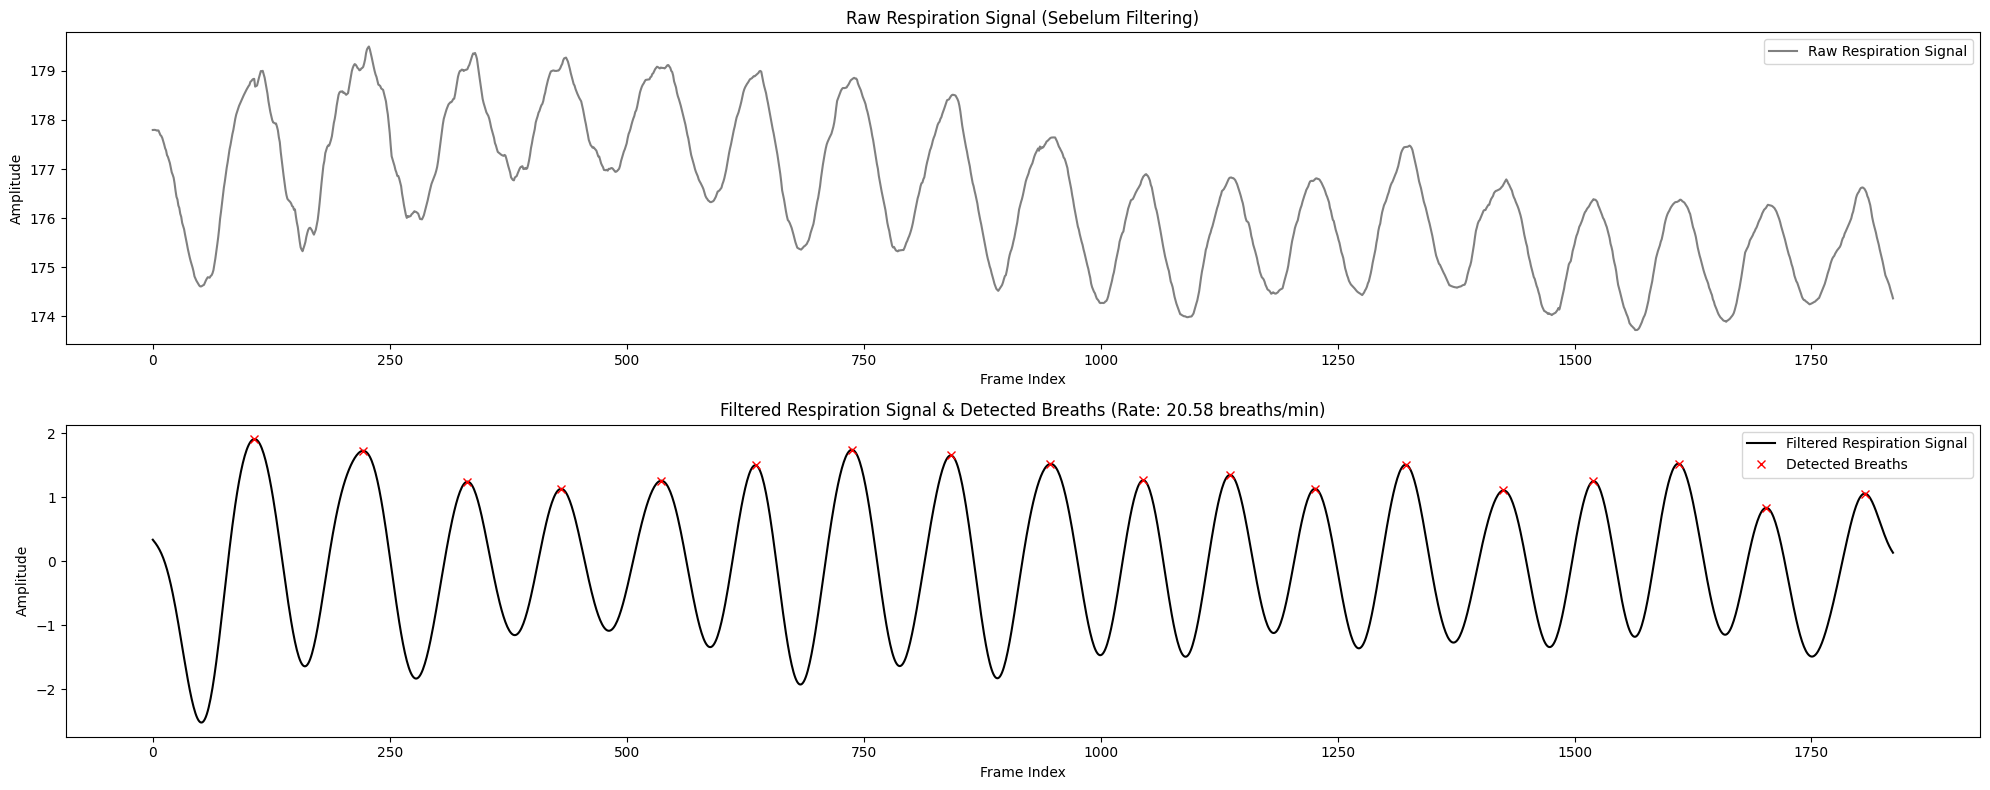

Laju Pernapasan: 20.58 breaths per minute


In [41]:
from scipy.signal import butter, filtfilt, find_peaks

# Parameter filter bandpass untuk sinyal pernapasan (biasanya 0.1-0.7 Hz)
fs = 35  # sampling rate (sudah didefinisikan sebelumnya)
lowcut = 0.1
highcut = 0.7
order = 3

# Desain filter bandpass
b, a = butter(order, [lowcut, highcut], btype='band', fs=fs)
filtered_resp = filtfilt(b, a, resp_signal)

# Deteksi puncak (setiap puncak = 1 siklus napas)
peaks, _ = find_peaks(filtered_resp, distance=fs*2)  # minimal 2 detik antar napas

# Hitung laju pernapasan (breaths per minute)
duration_seconds = len(filtered_resp) / fs
breaths_per_minute = 60 * len(peaks) / duration_seconds

# Plot hasil post-processing dan sinyal mentah (sebelum filtering) dalam subplot
plt.figure(figsize=(20, 8))

# Subplot 1: Sinyal mentah (raw)
plt.subplot(2, 1, 1)
plt.plot(resp_signal, label='Raw Respiration Signal', color='gray')
plt.title('Raw Respiration Signal (Sebelum Filtering)')
plt.xlabel('Frame Index')
plt.ylabel('Amplitude')
plt.legend()

# Subplot 2: Sinyal setelah filtering dan deteksi puncak
plt.subplot(2, 1, 2)
plt.plot(filtered_resp, label='Filtered Respiration Signal', color='black')
plt.plot(peaks, filtered_resp[peaks], 'rx', label='Detected Breaths')
plt.title(f'Filtered Respiration Signal & Detected Breaths (Rate: {breaths_per_minute:.2f} breaths/min)')
plt.xlabel('Frame Index')
plt.ylabel('Amplitude')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Laju Pernapasan: {breaths_per_minute:.2f} breaths per minute")

## Hasil Post-Processing Sinyal Respirasi

Sinyal pertama adalah sinyal respirasi mentah yang dihasilkan langsung dari pergerakan titik-titik pada bahu. Sinyal ini masih mengandung banyak komponen frekuensi rendah dan tinggi, sehingga bentuk gelombangnya tidak terlalu teratur dan terdapat variasi amplitudo serta baseline yang berubah-ubah.

Sinyal kedua adalah hasil setelah dilakukan post-processing, yaitu filtering dan deteksi puncak. Setelah diproses, sinyal menjadi lebih halus, periodik, dan baseline-nya lebih stabil. Puncak-puncak napas dapat dideteksi dengan jelas (ditandai dengan tanda silang merah), sehingga laju pernapasan per menit bisa dihitung secara akurat. Dengan demikian, post-processing sangat penting untuk menghilangkan noise dan membuat pola napas lebih mudah dianalisis.

# Analisis Sinyal Respirasi

<p>Menampilkan Banyaknya Napas yang di track secara manual menggunakan stopwatch</p>

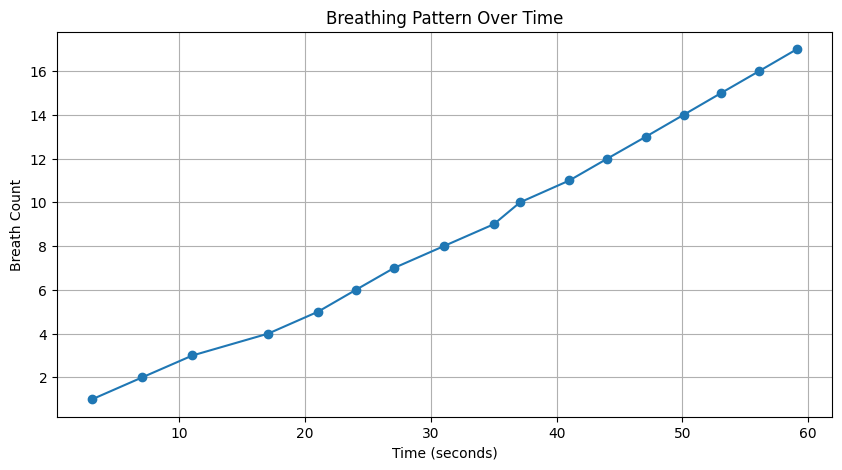

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("data_resp_bintang.csv")

# Gabungkan Second + Milisecond ke satu waktu dalam detik
df['Time (s)'] = df['Second'] + df['Milisecond'] / 1000.0

# Plot Line Plot
plt.figure(figsize=(10, 5))
plt.plot(df['Time (s)'], df['Nafas-ke'], marker='o')
plt.xlabel("Time (seconds)")
plt.ylabel("Breath Count")
plt.title("Breathing Pattern Over Time")
plt.grid(True)
plt.show()

## Membandingkan Jumlah Napas serta interval waktu tiap napas yang diperoleh antara Metode Manual dan Optical Flow

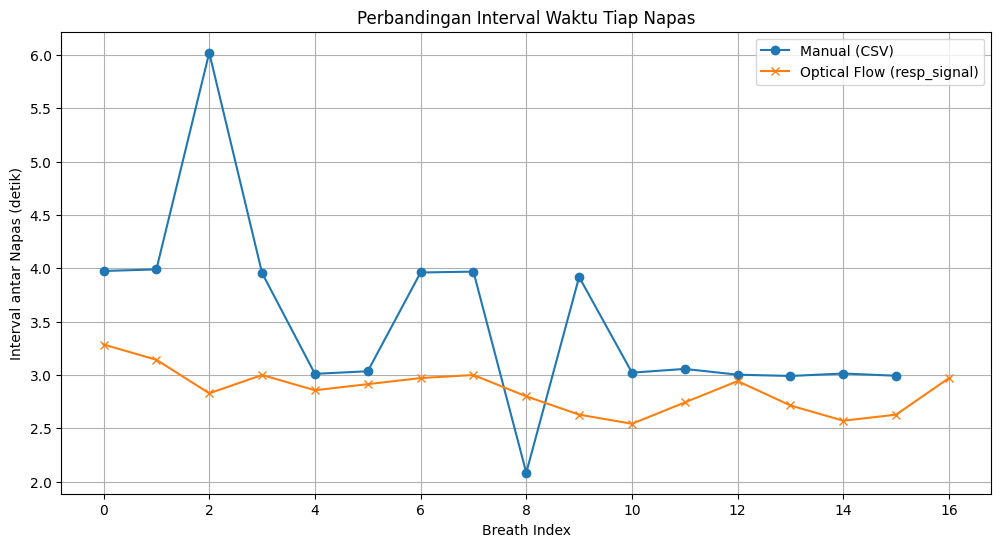

Jumlah napas (manual, CSV): 17
Jumlah napas (optical flow): 20.58


In [42]:
from scipy.signal import find_peaks

# Hitung puncak pada resp_signal (asumsi 1 puncak = 1 napas)
peaks_resp, _ = find_peaks(filtered_resp, distance=fs*2)  # asumsi minimal 2 detik antar napas

# Hitung waktu (detik) untuk tiap puncak pada resp_signal
times_resp = np.array(peaks_resp) / fs
intervals_resp = np.diff(times_resp)

# Hitung jumlah napas dari data manual (CSV)
jumlah_nafas_manual = df['Nafas-ke'].max()

# Hitung interval waktu antar napas dari data manual (CSV)
intervals_manual = df['Time (s)'].diff().dropna().values

# Plot perbandingan interval
plt.figure(figsize=(12, 6))
plt.plot(intervals_manual, label='Manual (CSV)', marker='o')
plt.plot(intervals_resp, label='Optical Flow (resp_signal)', marker='x')
plt.xlabel('Breath Index')
plt.ylabel('Interval antar Napas (detik)')
plt.title('Perbandingan Interval Waktu Tiap Napas')
plt.legend()
plt.grid(True)
plt.show()

# Tampilkan jumlah napas antara metode optical flow dan manual
print(f"Jumlah napas (manual, CSV): {jumlah_nafas_manual}")
print(f"Jumlah napas (optical flow): {breaths_per_minute:.2f}")

## Hasil Analisis
<p>Grafik di atas menunjukkan perbandingan interval waktu antar napas antara metode perhitungan manual dan Optical Flow. Hasil manual (garis biru) menunjukkan fluktuasi yang cukup besar, dengan beberapa interval napas yang jauh lebih panjang atau pendek. Hal ini kemungkinan disebabkan oleh ketidaktepatan pencatatan secara manual. Sebaliknya, hasil Optical Flow (garis oranye) tampak lebih stabil dan konsisten di sekitar nilai tertentu, menandakan deteksi otomatis lebih objektif dan minim bias manusia. Meski demikian, variasi alami napas lebih terlihat pada data manual, sedangkan Optical Flow cenderung menghasilkan interval yang seragam. Secara keseluruhan, Optical Flow dapat diandalkan untuk analisis napas otomatis. Jumlah napas yang didapatkan pada perhitungan manual dan perhitungan menggunakan optical flow hanya tidak jauh berbeda, menandakan metode Lucas-Kanade Optical Flow cukup efektif dalam mendeteksi sinyal respirasi.</p>

# LAMPIRAN

<h3>Referensi yang digunakan dalam membantu pengerjaan Hands On 3</h3>
<li><a href="https://github.com/bintangfikrif/DSP/blob/main/ho3/media/llm1.png">Percakapan 1 dengan Copilot</a></li>
<li><a href="https://github.com/bintangfikrif/DSP/blob/main/ho3/media/llm2.png">Percakapan 2 dengan Copilot</a></li>
<li><a href="https://github.com/bintangfikrif/DSP/blob/main/ho3/media/llm3.png">Percakapan 3 dengan Copilot</a></li>
<li><a href="https://github.com/bintangfikrif/DSP/blob/main/ho3/media/llm4.png">Percakapan 4 dengan Copilot</a></li>
<li><a href="https://medium.com/@guptachinmay321/an-insight-into-optical-flow-and-its-application-using-lucas-kanade-algorithm-c12f9f6e3773">Artikel Medium</a></li>

<h3>Video yang digunakan dalam percobaan</h3>
<a href="https://github.com/bintangfikrif/DSP/blob/main/ho3/media/Bintang_resp.mp4">Video respirasi</a>